# NUS ST5213 — Advanced Categorical Data Analysis
## Tutorial Case Study: Titanic Passenger Data

This single notebook develops the major ideas in advanced categorical data analysis through one real dataset downloaded directly inside Jupyter.

### Topics covered
- Contingency tables and conditional proportions
- Pearson chi-square tests
- Odds and odds ratios
- Stratified analysis and Mantel–Haenszel pooled odds ratios
- Generalized Linear Models (GLMs)
- Binary logistic regression
- Interactions and effect modification
- Maximum likelihood
- Wald and likelihood-ratio inference
- Deviance and goodness of fit
- Pearson/deviance residuals
- Leverage and Cook's distance
- Multinomial logistic regression
- Ordinal logistic regression
- Poisson regression for counts and rates
- Exposure offsets
- Overdispersion
- Log-linear models
- Independence and conditional independence
- Hierarchical interactions
- Model selection with AIC
- Predictive validation

### Case-study questions
1. Is sex associated with survival?
2. How large is the survival odds ratio?
3. Does the association persist after controlling for class?
4. How do age, fare, sex, class, and family size jointly affect survival?
5. Are interaction effects important?
6. Can embarkation port be modeled as a multinomial outcome?
7. Can passenger class be modeled as an ordered outcome?
8. Can grouped survival counts be modeled with Poisson GLMs?
9. How do log-linear models represent associations in contingency tables?

## 0. Environment setup
Uncomment the installation line if required.

In [1]:
# %pip install -q pandas numpy matplotlib scipy statsmodels scikit-learn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.miscmodels.ordinal_model import OrderedModel

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, log_loss
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Part I — Download and inspect a real dataset

The notebook downloads the Titanic dataset from the public `seaborn-data` repository:

`https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv`

In [3]:
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [5]:
df.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

## 1. Feature preparation

We create:

\[
\text{family\_size}=\text{sibsp}+\text{parch}+1
\]

and

\[
\text{log\_fare}=\log(1+\text{fare})
\]

because fare is strongly right-skewed.

In [6]:
data = df.copy()
data["family_size"] = data["sibsp"] + data["parch"] + 1
data["log_fare"] = np.log1p(data["fare"])

data[[
    "survived", "sex", "class", "pclass",
    "embarked", "age", "fare", "log_fare", "family_size"
]].head()

,survived,sex,class,pclass,embarked,age,fare,log_fare,family_size
0,0,male,Third,3,S,22.0000,7.2500,2.1102,2
1,1,female,First,1,C,38.0000,71.2833,4.2806,2
2,1,female,Third,3,S,26.0000,7.9250,2.1889,1
3,1,female,First,1,S,35.0000,53.1000,3.9908,2
4,0,male,Third,3,S,35.0000,8.0500,2.2028,1


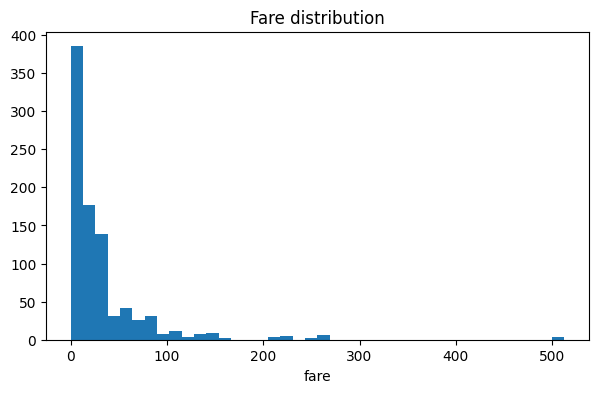

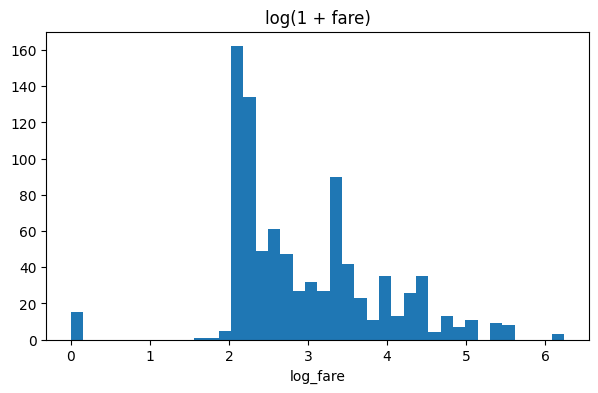

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(data["fare"].dropna(), bins=40)
ax.set_title("Fare distribution")
ax.set_xlabel("fare")
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(data["log_fare"].dropna(), bins=40)
ax.set_title("log(1 + fare)")
ax.set_xlabel("log_fare")
plt.show()

# Part II — Contingency tables

For categorical variables \(A\) and \(B\), a contingency table stores cell counts

\[
n_{ij}=\#\{A=i,B=j\}.
\]

We begin with **sex × survival**.

In [8]:
sex_survival = pd.crosstab(data["sex"], data["survived"], margins=True)
sex_survival

survived,0,1,All
sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


In [9]:
survival_prop = pd.crosstab(data["sex"], data["survived"], normalize="index")
survival_prop.columns = ["died", "survived"]
survival_prop

,died,survived
sex,,
female,0.2580,0.7420
male,0.8111,0.1889


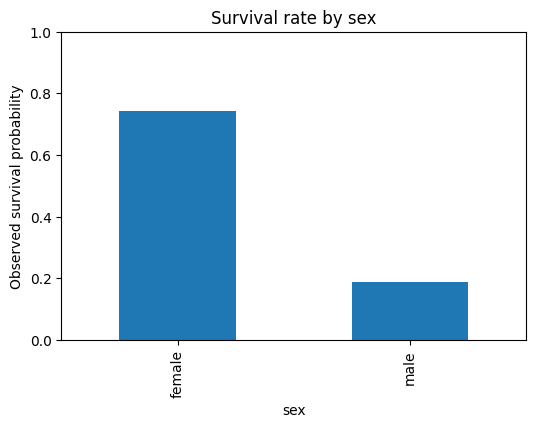

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
survival_prop["survived"].plot(kind="bar", ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel("Observed survival probability")
ax.set_title("Survival rate by sex")
plt.show()

## 2. Pearson chi-square test of independence

Null hypothesis:

\[
H_0: A\perp B
\]

Expected count:

\[
E_{ij}=\frac{(\text{row total})_i(\text{column total})_j}{N}
\]

Pearson statistic:

\[
X^2=\sum_{ij}\frac{(O_{ij}-E_{ij})^2}{E_{ij}}
\]

In [11]:
table = pd.crosstab(data["sex"], data["survived"])
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(f"Chi-square = {chi2:.4f}")
print(f"df         = {dof}")
print(f"p-value    = {p_value:.6g}")

expected_df = pd.DataFrame(expected, index=table.index, columns=table.columns)
expected_df

Chi-square = 260.7170
df         = 1
p-value    = 1.19736e-58


survived,0,1
sex,,
female,193.4747,120.5253
male,355.5253,221.4747


In [12]:
pearson_cell_resid = (table - expected_df) / np.sqrt(expected_df)
pearson_cell_resid

survived,0,1
sex,,
female,-8.0862,10.2451
male,5.9651,-7.5578


# Part III — Odds and odds ratios

For probability \(p\),

\[
\text{odds}=\frac{p}{1-p}.
\]

For a \(2\times2\) table, the odds ratio is

\[
OR=\frac{ad}{bc}.
\]

In [13]:
summary = data.groupby("sex")["survived"].agg(["sum","count"])
summary["failures"] = summary["count"] - summary["sum"]
summary["probability"] = summary["sum"] / summary["count"]
summary["odds"] = summary["probability"] / (1-summary["probability"])
summary

,sum,count,failures,probability,odds
sex,,,,,
female,233,314,81,0.7420,2.8765
male,109,577,468,0.1889,0.2329


In [14]:
female = data.loc[data["sex"]=="female", "survived"]
male = data.loc[data["sex"]=="male", "survived"]

a = female.sum()
b = len(female)-a
c = male.sum()
d = len(male)-c

odds_ratio = (a*d)/(b*c)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
z = stats.norm.ppf(0.975)
ci = np.exp([np.log(odds_ratio)-z*se_log_or, np.log(odds_ratio)+z*se_log_or])

print(f"Female vs male survival OR = {odds_ratio:.4f}")
print(f"95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")

Female vs male survival OR = 12.3507
95% CI = (8.9000, 17.1393)


# Part IV — Stratified analysis and confounding

A crude association can change after conditioning on a third variable. We stratify by passenger class.

In [15]:
def odds_ratio_2x2(tab):
    tab = tab.reindex(index=["female","male"], columns=[0,1], fill_value=0)
    fd, fs = tab.loc["female",0], tab.loc["female",1]
    md, ms = tab.loc["male",0], tab.loc["male",1]
    return (fs*md)/(fd*ms)

for cls in ["First","Second","Third"]:
    sub = data[data["class"]==cls]
    tab = pd.crosstab(sub["sex"], sub["survived"])
    print("\n", cls)
    display(tab)
    print("OR =", odds_ratio_2x2(tab))


 First


survived,0,1
sex,,
female,3,91
male,77,45


OR = 51.903703703703705

 Second


survived,0,1
sex,,
female,6,70
male,91,17


OR = 62.450980392156865

 Third


survived,0,1
sex,,
female,72,72
male,300,47


OR = 6.382978723404255


## 3. Mantel–Haenszel pooled odds ratio

The Mantel–Haenszel estimator combines several stratified \(2\times2\) tables to estimate an association while controlling for the stratifying variable.

In [16]:
tables = []
for cls in ["First","Second","Third"]:
    sub = data[data["class"]==cls]
    tab = pd.crosstab(sub["sex"], sub["survived"])
    tab = tab.reindex(index=["female","male"], columns=[1,0], fill_value=0)
    tables.append(tab.to_numpy())

stacked = np.stack(tables, axis=2)
mh = StratifiedTable(stacked)

print("Pooled OR:", mh.oddsratio_pooled)
print("95% CI:", mh.oddsratio_pooled_confint())
print(mh.test_null_odds())

Pooled OR: 13.758600320664655
95% CI: (9.592900296135637, 19.733248229427556)
pvalue      0.0
statistic   250.4473449438795


# Part V — Generalized Linear Models

A GLM has:

1. **Random component**: distribution of \(Y\)
2. **Systematic component**:

\[
\eta=X\beta
\]

3. **Link function**:

\[
g(E[Y|X])=X\beta
\]

Important examples:

| Response | Distribution | Link |
|---|---|---|
| continuous | Gaussian | identity |
| binary | Binomial | logit |
| count | Poisson | log |

# Part VI — Binary logistic regression

For

\[
Y_i\sim Bernoulli(p_i),
\]

the logistic model is

\[
\log\frac{p_i}{1-p_i}=X_i^\top\beta.
\]

Exponentiating a coefficient gives an adjusted odds ratio.

In [28]:
model_df = data[[
    "survived","sex","class","age","log_fare","family_size"
]].dropna().copy()

logit_model = smf.glm(
    'survived ~ C(sex) + C(Q("class")) + age + log_fare + family_size',
    data=model_df,
    family=sm.families.Binomial()
).fit()

print(logit_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      707
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -318.86
Date:                Sun, 30 Aug 2026   Deviance:                       637.71
Time:                        15:06:27   Pearson chi2:                     735.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3673
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [29]:
coef_table = pd.DataFrame({
    "coef": logit_model.params,
    "std_error": logit_model.bse,
    "odds_ratio": np.exp(logit_model.params),
    "ci_low": np.exp(logit_model.conf_int()[0]),
    "ci_high": np.exp(logit_model.conf_int()[1]),
    "p_value": logit_model.pvalues
})
coef_table

,coef,std_error,odds_ratio,ci_low,ci_high,p_value
Intercept,3.6440,0.8502,38.2434,7.2260,202.4031,0.0000
C(sex)[T.male],-2.6438,0.2192,0.0711,0.0463,0.1092,0.0000
"C(Q(""class""))[T.Second]",-1.1461,0.3472,0.3179,0.1610,0.6277,0.0010
"C(Q(""class""))[T.Third]",-2.2478,0.4176,0.1056,0.0466,0.2395,0.0000
age,-0.0426,0.0082,0.9583,0.9430,0.9738,0.0000
log_fare,0.2287,0.1887,1.2570,0.8683,1.8195,0.2256
family_size,-0.2604,0.0883,0.7707,0.6483,0.9163,0.0032


## 4. Predicted probabilities

In [30]:
profiles = pd.DataFrame({
    "sex": ["male","female","male","female"],
    "class": ["First","First","Third","Third"],
    "age": [30,30,30,30],
    "log_fare": np.log1p([80,80,10,10]),
    "family_size": [1,1,1,1]
})
profiles["p_survive"] = logit_model.predict(profiles)
profiles

,sex,class,age,log_fare,family_size,p_survive
0,male,First,30,4.3944,1,0.6145
1,female,First,30,4.3944,1,0.9573
2,male,Third,30,2.3979,1,0.0964
3,female,Third,30,2.3979,1,0.6001


# Part VII — Interaction effects

An interaction allows one predictor's effect to depend on another:

\[
\text{logit}(p)=\beta_0+\beta_1X+\beta_2Z+\beta_3XZ+\cdots
\]

In [33]:
interaction_model = smf.glm(
    'survived ~ C(sex)*C(Q("class")) + age + log_fare + family_size',
    data=model_df,
    family=sm.families.Binomial()
).fit()

print(interaction_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      705
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -302.75
Date:                Sun, 30 Aug 2026   Deviance:                       605.50
Time:                        15:06:50   Pearson chi2:                     797.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3952
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

# Part VIII — Likelihood inference

For Bernoulli data,

\[
L(\beta)=\prod_i p_i^{y_i}(1-p_i)^{1-y_i}.
\]

Logistic regression estimates \(\beta\) by maximizing this likelihood numerically.

In [32]:
print("Log-likelihood:", logit_model.llf)
print("Null log-likelihood:", logit_model.llnull)
print("Deviance:", logit_model.deviance)
print("Null deviance:", logit_model.null_deviance)

Log-likelihood: -318.8572310082959
Null log-likelihood: -482.2579824277625
Deviance: 637.7144620165918
Null deviance: 964.515964855525


## 5. Wald tests

\[
z=\frac{\hat\beta_j}{SE(\hat\beta_j)}
\]

tests \(H_0:\beta_j=0\).

In [34]:
pd.DataFrame({
    "estimate": logit_model.params,
    "SE": logit_model.bse,
    "z": logit_model.tvalues,
    "p_value": logit_model.pvalues
})

,estimate,SE,z,p_value
Intercept,3.6440,0.8502,4.2862,0.0000
C(sex)[T.male],-2.6438,0.2192,-12.0597,0.0000
"C(Q(""class""))[T.Second]",-1.1461,0.3472,-3.3012,0.0010
"C(Q(""class""))[T.Third]",-2.2478,0.4176,-5.3823,0.0000
age,-0.0426,0.0082,-5.2041,0.0000
log_fare,0.2287,0.1887,1.2118,0.2256
family_size,-0.2604,0.0883,-2.9501,0.0032


## 6. Likelihood-ratio test

For nested models,

\[
G^2=2(\ell_\text{full}-\ell_\text{reduced})
\]

and asymptotically

\[
G^2\sim\chi^2_{\Delta df}.
\]

In [35]:
lr_stat = 2*(interaction_model.llf-logit_model.llf)
df_diff = interaction_model.df_model-logit_model.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)

print("LR statistic:", lr_stat)
print("df:", df_diff)
print("p-value:", lr_p)

LR statistic: 32.216476709643075
df: 2
p-value: 1.0099060393073203e-07


## 7. Score-test concept

The three standard large-sample tests are:

- **Wald**: distance of fitted estimate from null
- **Likelihood ratio**: difference in maximized likelihood
- **Score**: slope of likelihood evaluated at the null

They are asymptotically equivalent under regularity conditions.

# Part IX — Prediction and classification metrics

In [36]:
pred_prob = logit_model.predict(model_df)
pred = (pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(model_df["survived"], pred))
print("ROC AUC:", roc_auc_score(model_df["survived"], pred_prob))
print("Log loss:", log_loss(model_df["survived"], pred_prob))
print("\nConfusion matrix:\n", confusion_matrix(model_df["survived"], pred))
print("\n", classification_report(model_df["survived"], pred, digits=4))

Accuracy: 0.7997198879551821
ROC AUC: 0.8584661678594665
Log loss: 0.44657875491357973

Confusion matrix:
 [[361  63]
 [ 80 210]]

               precision    recall  f1-score   support

           0     0.8186    0.8514    0.8347       424
           1     0.7692    0.7241    0.7460       290

    accuracy                         0.7997       714
   macro avg     0.7939    0.7878    0.7903       714
weighted avg     0.7985    0.7997    0.7987       714



# Part X — GLM diagnostics

Deviance measures discrepancy from a saturated model:

\[
D=2[\ell(\text{saturated})-\ell(\text{fitted})].
\]

In [37]:
print("Null deviance:", logit_model.null_deviance)
print("Residual deviance:", logit_model.deviance)
print("Residual df:", logit_model.df_resid)

Null deviance: 964.515964855525
Residual deviance: 637.7144620165918
Residual df: 707


In [38]:
diag = model_df.copy()
diag["fitted"] = logit_model.fittedvalues
diag["pearson_resid"] = logit_model.resid_pearson
diag["deviance_resid"] = logit_model.resid_deviance
diag.head()

,survived,sex,class,age,log_fare,family_size,fitted,pearson_resid,deviance_resid
0,0,male,Third,22.0000,2.1102,2,0.0977,-0.3290,-0.4534
1,1,female,First,38.0000,4.2806,2,0.9229,0.2890,0.4005
2,1,female,Third,26.0000,2.1889,1,0.6291,0.7678,0.9627
3,1,female,First,35.0000,3.9908,2,0.9272,0.2802,0.3888
4,0,male,Third,35.0000,2.2028,1,0.0762,-0.2871,-0.3981


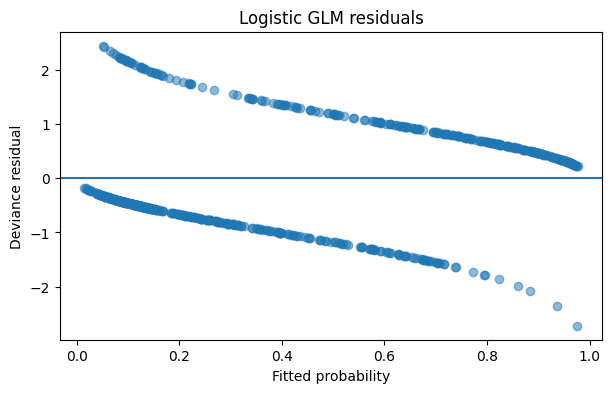

In [39]:
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(diag["fitted"], diag["deviance_resid"], alpha=0.5)
ax.axhline(0)
ax.set_xlabel("Fitted probability")
ax.set_ylabel("Deviance residual")
ax.set_title("Logistic GLM residuals")
plt.show()

## 8. Leverage and influence

High leverage means an unusual predictor configuration. Cook's distance summarizes influence on the fitted model.

In [40]:
influence = logit_model.get_influence()
infl = influence.summary_frame()

infl[["hat_diag","cooks_d","standard_resid"]].sort_values(
    "cooks_d", ascending=False
).head(10)

,hat_diag,cooks_d,standard_resid
271,0.0138,0.0265,3.6458
297,0.0039,0.0220,-6.2676
261,0.0133,0.0215,3.3472
838,0.0180,0.0186,2.6686
74,0.0180,0.0186,2.6686
509,0.0209,0.0169,2.3519
25,0.0309,0.0164,1.8983
630,0.0161,0.0156,2.5857
68,0.0510,0.0155,1.4210
570,0.0081,0.0141,3.4865


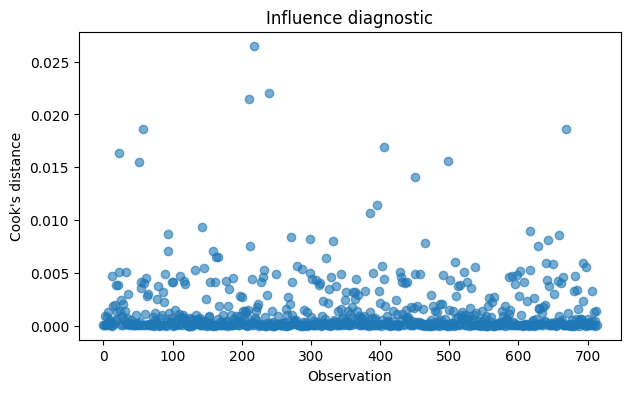

In [41]:
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(np.arange(len(infl)), infl["cooks_d"], alpha=0.6)
ax.set_xlabel("Observation")
ax.set_ylabel("Cook's distance")
ax.set_title("Influence diagnostic")
plt.show()

# Part XI — Multinomial logistic regression

For unordered response categories \(1,\dots,J\), choose a baseline \(J\):

\[
\log\frac{P(Y=j)}{P(Y=J)}
=\alpha_j+X^\top\beta_j.
\]

We model embarkation port (`S`, `C`, `Q`).

In [42]:
multi_df = data[[
    "embarked","sex","pclass","age","log_fare","family_size"
]].dropna().copy()

multi_df["embarked_code"] = pd.Categorical(
    multi_df["embarked"], categories=["S","C","Q"]
).codes

X_multi = pd.get_dummies(
    multi_df[["sex","pclass","age","log_fare","family_size"]],
    columns=["sex"],
    drop_first=True,
    dtype=float
)
X_multi = sm.add_constant(X_multi)

mnlogit = sm.MNLogit(multi_df["embarked_code"], X_multi).fit(
    method="newton", maxiter=100, disp=False
)
print(mnlogit.summary())

                          MNLogit Regression Results                          
Dep. Variable:          embarked_code   No. Observations:                  712
Model:                        MNLogit   Df Residuals:                      700
Method:                           MLE   Df Model:                           10
Date:                Sun, 30 Aug 2026   Pseudo R-squ.:                  0.1093
Time:                        15:07:02   Log-Likelihood:                -401.44
converged:                       True   LL-Null:                       -450.68
Covariance Type:            nonrobust   LLR p-value:                 1.096e-16
embarked_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -3.1257      1.113     -2.808      0.005      -5.307      -0.944
pclass             -0.0581      0.229     -0.253      0.800      -0.507       0.391
age                -0.0125      

In [43]:
multi_probs = mnlogit.predict(X_multi)
multi_probs.columns = ["S","C","Q"]
multi_probs.head()

,S,C,Q
0,0.8806,0.0660,0.0534
1,0.5997,0.3930,0.0073
2,0.7976,0.1122,0.0902
3,0.6529,0.3394,0.0077
4,0.8544,0.0859,0.0597


In [44]:
multi_pred = multi_probs.idxmax(axis=1).reset_index(drop=True)
multi_true = multi_df["embarked"].reset_index(drop=True)
print("Accuracy:", (multi_pred == multi_true).mean())

Accuracy: 0.7879213483146067


# Part XII — Ordinal logistic regression

Passenger class has an ordering:

\[
Third < Second < First.
\]

A proportional-odds cumulative-logit model has the form

\[
\log\frac{P(Y\le j)}{P(Y>j)}
=\theta_j-X^\top\beta.
\]

The same slope \(\beta\) is used across cumulative splits: the **proportional-odds assumption**.

In [45]:
ordinal_df = data[[
    "class","sex","age","log_fare","family_size"
]].dropna().copy()

order = ["Third","Second","First"]
ordinal_df["class_ord"] = pd.Categorical(
    ordinal_df["class"], categories=order, ordered=True
)

X_ord = pd.get_dummies(
    ordinal_df[["sex","age","log_fare","family_size"]],
    columns=["sex"],
    drop_first=True,
    dtype=float
)

ord_model = OrderedModel(
    ordinal_df["class_ord"],
    X_ord,
    distr="logit"
)
ord_result = ord_model.fit(method="bfgs", disp=False)
print(ord_result.summary())

                             OrderedModel Results                             
Dep. Variable:              class_ord   Log-Likelihood:                -326.70
Model:                   OrderedModel   AIC:                             665.4
Method:            Maximum Likelihood   BIC:                             692.8
Date:                Sun, 30 Aug 2026                                         
Time:                        15:07:03                                         
No. Observations:                 714                                         
Df Residuals:                     708                                         
Df Model:                           4                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
age              0.0359      0.008      4.583      0.000       0.021       0.051
log_fare         4.8447      0.301     16.072 

In [46]:
ord_probs = pd.DataFrame(
    ord_result.model.predict(ord_result.params, exog=X_ord),
    columns=order
)
ord_probs.head()

,Third,Second,First
0,0.9810,0.0185,0.0005
1,0.0005,0.0216,0.9778
2,0.8389,0.1565,0.0046
3,0.0025,0.0907,0.9068
4,0.8363,0.1590,0.0047


# Part XIII — Poisson regression

For count data,

\[
Y_i\sim Poisson(\mu_i),
\qquad
\log\mu_i=X_i^\top\beta.
\]

In [47]:
count_df = (
    data.dropna(subset=["sex","class","embarked","survived"])
        .groupby(["sex","class","embarked"], observed=True)
        .agg(passengers=("survived","size"), survivors=("survived","sum"))
        .reset_index()
)
count_df

,sex,class,embarked,passengers,survivors
0,female,First,C,43,42
1,female,First,Q,1,1
2,female,First,S,48,46
3,female,Second,C,7,7
4,female,Second,Q,2,2
5,female,Second,S,67,61
6,female,Third,C,23,15
7,female,Third,Q,33,24
8,female,Third,S,88,33
9,male,First,C,42,17


## 9. Exposure offsets

To model rates instead of raw counts:

\[
\log E(Y_i)=\log(n_i)+X_i^\top\beta.
\]

The term \(\log(n_i)\) is an **offset** with coefficient fixed at 1.

In [52]:
count_df["log_exposure"] = np.log(count_df["passengers"])

poisson_model = smf.glm(
    'survivors ~ C(sex) + C(Q("class")) + C(embarked)',
    data=count_df,
    family=sm.families.Poisson(),
    offset=count_df["log_exposure"]
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              survivors   No. Observations:                   18
Model:                            GLM   Df Residuals:                       12
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -42.711
Date:                Sun, 30 Aug 2026   Deviance:                       15.335
Time:                        15:07:17   Pearson chi2:                     14.3
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [53]:
pd.DataFrame({
    "coef": poisson_model.params,
    "rate_ratio": np.exp(poisson_model.params),
    "ci_low": np.exp(poisson_model.conf_int()[0]),
    "ci_high": np.exp(poisson_model.conf_int()[1])
})

,coef,rate_ratio,ci_low,ci_high
Intercept,0.1545,1.1671,0.9342,1.4580
C(sex)[T.male],-1.2468,0.2874,0.2280,0.3623
"C(Q(""class""))[T.Second]",-0.1956,0.8224,0.6176,1.0950
"C(Q(""class""))[T.Third]",-0.7627,0.4664,0.3555,0.6120
C(embarked)[T.Q],0.0775,1.0806,0.6905,1.6910
C(embarked)[T.S],-0.1921,0.8252,0.6359,1.0711


# Part XIV — Overdispersion

Poisson assumes

\[
Var(Y|X)=E(Y|X).
\]

A rough dispersion estimate is

\[
\hat\phi=\frac{\sum r_{P,i}^2}{df_{resid}}.
\]

Values much larger than 1 suggest overdispersion.

In [54]:
pearson_chi2 = np.sum(poisson_model.resid_pearson**2)
dispersion = pearson_chi2 / poisson_model.df_resid

print("Pearson chi-square:", pearson_chi2)
print("Residual df:", poisson_model.df_resid)
print("Dispersion:", dispersion)

Pearson chi-square: 14.25777011025853
Residual df: 12
Dispersion: 1.1881475091882108


# Part XV — Log-linear models

For contingency-table cell counts,

\[
N_{ijk}\sim Poisson(\mu_{ijk}).
\]

A saturated three-variable model is

\[
\log\mu_{ijk}
=
\lambda+\lambda_i^S+\lambda_j^C+\lambda_k^Y
+\lambda_{ij}^{SC}+\lambda_{ik}^{SY}+\lambda_{jk}^{CY}
+\lambda_{ijk}^{SCY}.
\]

Interactions represent associations between categorical variables.

In [55]:
loglin_df = (
    data.dropna(subset=["sex","class","survived"])
        .groupby(["sex","class","survived"], observed=True)
        .size()
        .reset_index(name="count")
)
loglin_df

,sex,class,survived,count
0,female,First,0,3
1,female,First,1,91
2,female,Second,0,6
3,female,Second,1,70
4,female,Third,0,72
5,female,Third,1,72
6,male,First,0,77
7,male,First,1,45
8,male,Second,0,91
9,male,Second,1,17


## 10. Mutual independence model

\[
[S][C][Y]
\]

In [63]:
ll_ind = smf.glm(
    'count ~ C(sex) + C(Q("class")) + C(survived)',
    data=loglin_df,
    family=sm.families.Poisson()
).fit()

print(ll_ind.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                   12
Model:                            GLM   Df Residuals:                        7
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -236.46
Date:                Sun, 30 Aug 2026   Deviance:                       405.49
Time:                        15:08:16   Pearson chi2:                     420.
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## 11. Pairwise-association model

\[
[SC][SY][CY]
\]

In [64]:
ll_pair = smf.glm(
    """count ~ C(sex) + C(Q("class")) + C(survived)
             + C(sex):C(Q("class"))
             + C(sex):C(survived)
             + C(Q("class")):C(survived)""",
    data=loglin_df,
    family=sm.families.Poisson()
).fit()

print(ll_pair.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                   12
Model:                            GLM   Df Residuals:                        2
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -48.106
Date:                Sun, 30 Aug 2026   Deviance:                       28.791
Time:                        15:08:16   Pearson chi2:                     26.7
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

## 12. Saturated model

\[
[SCY]
\]

In [65]:
ll_sat = smf.glm(
    'count ~ C(sex) * C(Q("class")) * C(survived)',
    data=loglin_df,
    family=sm.families.Poisson()
).fit()

print("Deviance:", ll_sat.deviance)
print("Residual df:", ll_sat.df_resid)

Deviance: 2.7533531010699376e-14
Residual df: 0


/home/anirban/polyglot-jupyter/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


# Part XVI — Hierarchical model comparison

For nested log-linear models,

\[
\Delta D=D_\text{reduced}-D_\text{full}
\sim\chi^2_{\Delta df}.
\]

In [66]:
def lr_compare(reduced, full):
    lr = reduced.deviance - full.deviance
    df_diff = reduced.df_resid - full.df_resid
    p = stats.chi2.sf(lr, df_diff)
    return pd.Series({
        "LR statistic": lr,
        "df difference": df_diff,
        "p-value": p
    })

print("Independence vs pairwise")
display(lr_compare(ll_ind, ll_pair))

print("Pairwise vs saturated")
display(lr_compare(ll_pair, ll_sat))

Independence vs pairwise


LR statistic    376.7010
df difference     5.0000
p-value           0.0000
dtype: float64

Pairwise vs saturated


LR statistic    28.7915
df difference    2.0000
p-value          0.0000
dtype: float64

# Part XVII — Conditional independence

To test whether sex and survival are conditionally independent after accounting for passenger class, compare a model without `sex:survived` against one containing it.

In [69]:
ll_no_sex_surv = smf.glm(
    """count ~ C(sex) + C(Q("class")) + C(survived)
             + C(sex):C(Q("class"))
             + C(Q("class")):C(survived)""",
    data=loglin_df,
    family=sm.families.Poisson()
).fit()

lr_compare(ll_no_sex_surv, ll_pair)

LR statistic    256.2196
df difference     1.0000
p-value           0.0000
dtype: float64

# Part XVIII — Poisson goodness-of-fit diagnostics

In [70]:
count_diag = count_df.copy()
count_diag["fitted"] = poisson_model.fittedvalues
count_diag["pearson_resid"] = poisson_model.resid_pearson
count_diag["deviance_resid"] = poisson_model.resid_deviance

count_diag.sort_values(
    "deviance_resid",
    key=np.abs,
    ascending=False
).head(10)

,sex,class,embarked,passengers,survivors,log_exposure,fitted,pearson_resid,deviance_resid
14,male,Second,S,97,15,4.5747,22.0830,-1.5073,-1.6010
16,male,Third,Q,39,3,3.6636,6.5936,-1.3995,-1.5692
11,male,First,S,79,28,4.3694,21.8702,1.3107,1.2557
0,female,First,C,43,42,3.7612,50.1856,-1.1555,-1.1892
15,male,Third,C,43,10,3.7612,6.7279,1.2615,1.1757
8,female,Third,S,88,33,4.4773,39.5314,-1.0388,-1.0696
5,female,Second,S,67,61,4.2047,53.0676,1.0889,1.0633
7,female,Third,Q,33,24,3.4965,19.4105,1.0417,1.0042
10,male,First,Q,1,0,0.0000,0.3625,-0.6021,-0.8515
13,male,Second,Q,1,0,0.0000,0.2981,-0.5460,-0.7721


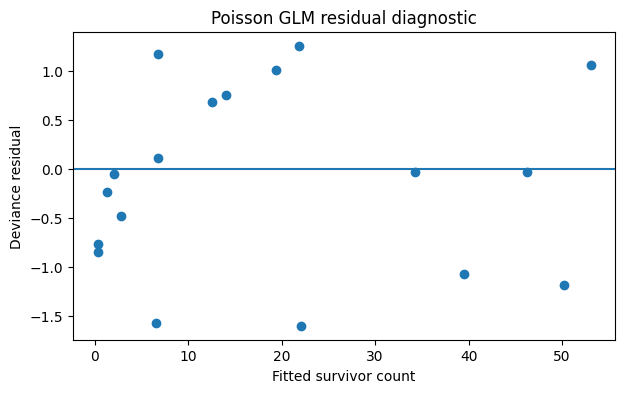

In [71]:
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(poisson_model.fittedvalues, poisson_model.resid_deviance)
ax.axhline(0)
ax.set_xlabel("Fitted survivor count")
ax.set_ylabel("Deviance residual")
ax.set_title("Poisson GLM residual diagnostic")
plt.show()

# Part XIX — Model selection

AIC:

\[
AIC=-2\ell(\hat\theta)+2k.
\]

Lower AIC is preferred among models fitted to the same response dataset.

In [72]:
pd.DataFrame({
    "model": ["main effects", "sex × class interaction"],
    "log_likelihood": [logit_model.llf, interaction_model.llf],
    "AIC": [logit_model.aic, interaction_model.aic],
    "deviance": [logit_model.deviance, interaction_model.deviance],
    "df_model": [logit_model.df_model, interaction_model.df_model]
})

,model,log_likelihood,AIC,deviance,df_model
0,main effects,-318.8572,651.7145,637.7145,6
1,sex × class interaction,-302.7490,623.4980,605.4980,8


# Part XX — Out-of-sample validation

In [75]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df["survived"]
)

train_model = smf.glm(
    'survived ~ C(sex) + C(Q("class")) + age + log_fare + family_size',
    data=train_df,
    family=sm.families.Binomial()
).fit()

test_prob = train_model.predict(test_df)
test_pred = (test_prob >= 0.5).astype(int)

print("Test accuracy:", accuracy_score(test_df["survived"], test_pred))
print("Test ROC AUC:", roc_auc_score(test_df["survived"], test_prob))
print("Test log loss:", log_loss(test_df["survived"], test_prob))

Test accuracy: 0.7821229050279329
Test ROC AUC: 0.8617859912121993
Test log loss: 0.44817044656471344


# Part XXI — Scenario-based interpretation

In [76]:
scenario = pd.DataFrame({
    "sex": ["male","female","male","female","male","female"],
    "class": ["First","First","Second","Second","Third","Third"],
    "age": [30]*6,
    "log_fare": np.log1p([70,70,25,25,10,10]),
    "family_size": [1]*6
})
scenario["p_survive"] = interaction_model.predict(scenario)
scenario

,sex,class,age,log_fare,family_size,p_survive
0,male,First,30,4.2627,1,0.5787
1,female,First,30,4.2627,1,0.9810
2,male,Second,30,3.2581,1,0.1643
3,female,Second,30,3.2581,1,0.9445
4,male,Third,30,2.3979,1,0.1398
5,female,Third,30,2.3979,1,0.4412


In [77]:
scenario.pivot(index="class", columns="sex", values="p_survive").reindex(
    ["First","Second","Third"]
)

sex,female,male
class,,
First,0.9810,0.5787
Second,0.9445,0.1643
Third,0.4412,0.1398


# Part XXII — Key statistical connections

## Contingency tables ↔ logistic regression

For a binary predictor,

\[
\logit P(Y=1|X)=\beta_0+\beta_1X
\]

and

\[
e^{\beta_1}
\]

is the odds ratio. Logistic regression generalizes the \(2\times2\) analysis to multiple predictors, confounding adjustment, continuous covariates, and interactions.

## Logistic regression ↔ log-linear models

Logistic regression models conditional probabilities:

\[
P(Y|X).
\]

Log-linear models model expected contingency-table cell counts:

\[
E(N_{ijk}).
\]

Both are likelihood-based exponential-family models, and suitable log-linear models imply the same conditional odds-ratio structure as corresponding logistic models.

# Part XXIII — Experimentation exercises

Use these to turn the notebook into a deeper ST5213 lab.

1. **Remove fare** from the logistic model and compare coefficient shifts, likelihood, deviance, AIC and ROC AUC.
2. **Add nonlinear age terms** such as `age + I(age**2)` and use an LR test.
3. Try **sex × age**, **class × age**, and **sex × class** interactions.
4. Compare the crude odds ratio, class-specific odds ratios, Mantel–Haenszel pooled OR and regression-adjusted OR.
5. Create an ordinal fare-band response and fit another proportional-odds model.
6. Create a three-level family-size response and fit another multinomial model.
7. Perform forward log-linear model building by adding one interaction at a time.
8. Examine observations with the largest Cook's distances and identify their passenger characteristics.
9. Try a **Negative Binomial GLM** if the Poisson dispersion statistic suggests overdispersion.
10. Change the probability threshold from 0.5 and study precision/recall trade-offs.

# Final summary

The notebook has moved through the categorical-data hierarchy:

```text
Contingency tables
    ↓
Chi-square association
    ↓
Odds and odds ratios
    ↓
Stratification / Mantel-Haenszel
    ↓
Generalized Linear Models
    ↓
Binary logistic regression
    ↓
Interactions + likelihood inference
    ↓
Multinomial and ordinal models
    ↓
Poisson counts and rates
    ↓
Log-linear contingency-table models
    ↓
Conditional independence
    ↓
Diagnostics and model selection
```

The unifying idea is that categorical-data methods are not isolated algorithms. They are closely connected through **probability distributions, likelihoods, link functions, odds-ratio structures, and hierarchical interaction models**.